Step 1: Load your clean data

Load (`sales_clean.csv`) and confirm its shape matches what you saved in Lab 3.

In [1]:
import pandas as pd

df = pd.read_csv("sales_clean.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (289, 6)


,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


Step 2: Center and spread of price and qty

Compute mean, median, and standard deviation for `price` and for `qty` (Tutorial 1 pattern).

You should see: six numbers. The price mean sits noticeably above the price median; that gap is seeded skew.

In [2]:
summary_stats = df[["price", "qty"]].agg(["mean", "median", "std"])

print(summary_stats)

            price       qty
mean    55.723633  2.979239
median  37.530000  3.000000
std     72.105147  1.409141


Step 3: Which summary would you report? (markdown cell)

Which of mean or median would you report for price, and why? 2–3 sentences.

I would report the median for the price variable instead of the mean. Looking at the overall distribution, I feel that the median is more representative of a standard transaction's price than the mean. The mean is less representative because the dataset is right-skewed due to some high-value outliers.

Step 4: Histogram of price

Plot a histogram of price with about 20 bins (Tutorial 2) and, in a markdown line, name its shape.

You should see: a right-skewed histogram: most prices low, a tail of expensive items.

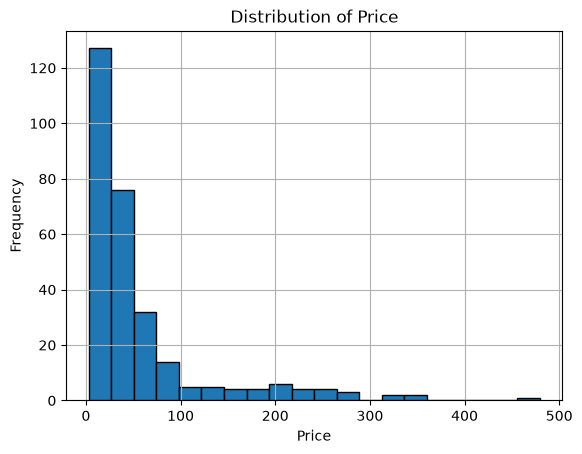

In [3]:
import matplotlib.pyplot as plt

df["price"].hist(bins=20, edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Checkpoint: Your histogram’s shape agrees with your Step 3 choice (skew favors the median). If they disagree, reread Tutorial 1.

Check! The graph is right-skewed, meaning there are more items at lower price points and the "tail" points to the right, showing the higher-priced outliers.

Step 5: Create the revenue column

Make `revenue = price * qty` as a new column (Tutorial 3 pattern).

You should see: a 7th column appears in `df.head().`

In [4]:
df["revenue"] = df["price"] * df["qty"]

print("Updated dataset shape:", df.shape)
df.head()

Updated dataset shape: (289, 7)


,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


Step 6: Correlation matrix

Compute the correlation matrix of the numeric columns (Tutorial 4). Note the strongest off-diagonal value.

You should see: a matrix; qty vs. revenue should be the standout.

In [5]:
corr_matrix = df.select_dtypes(include="number").corr()
print(corr_matrix)

          order_id     price       qty       zip   revenue
order_id  1.000000 -0.004081  0.026030 -0.016886  0.003909
price    -0.004081  1.000000 -0.040190  0.023194  0.821184
qty       0.026030 -0.040190  1.000000  0.080835  0.313952
zip      -0.016886  0.023194  0.080835  1.000000  0.044752
revenue   0.003909  0.821184  0.313952  0.044752  1.000000


Step 7: Scatter to verify

Scatter-plot `qty` against `revenue` (Tutorial 5) and check the cloud agrees with the r value.

You should see: an upward-drifting cloud.

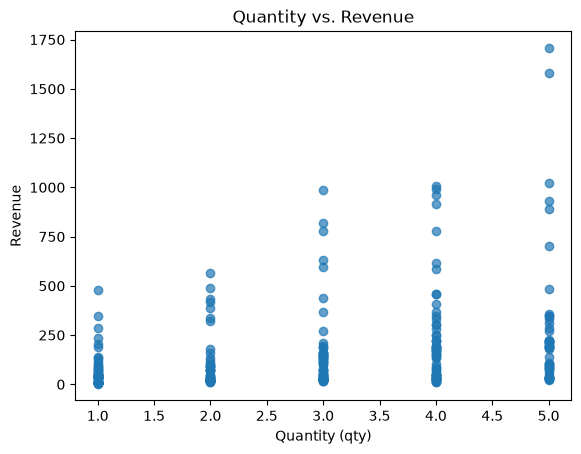

In [6]:
plt.scatter(df["qty"], df["revenue"], alpha=0.7)
plt.title("Quantity vs. Revenue")
plt.xlabel("Quantity (qty)")
plt.ylabel("Revenue")
plt.show()

Step 8: The analyst’s sentence (markdown cell)

One plain-English claim: the relationship, its strength, and one caution (a confounder or outlier risk). This is the deliverable that matters most.

The relationship between quantity sold and total revenue is strongly positive, with a Pearson coefficient of approximately 0.82, indicating that transactions with higher quantities of items sold tend to generate higher revenue. The outlier risk to keep in mind is that this relationship could be influenced by bulk orders with special pricing tiers. 

Step 9: By-hand check

In a markdown cell, compute the mean and median of [2, 4, 4, 6, 9] by hand, then verify both with Python.

You should see: mean 5.0, median 4, in both places.


Given the list: `[2, 4, 4, 6, 9]`

Mean calculation:
   - Sum = $2 + 4 + 4 + 6 + 9 = 25$
   - Count = $5$
   - Mean = $25 / 5 = 5.0$

Median calculation:
   - Ordered list: `2, 4, 4, 6, 9`
   - Middle element (3rd position) = $4$
   - Median = $4$

Given the list: `[2, 4, 4, 6, 9]`

Mean calculation:
   - Sum = `2 + 4 + 4 + 6 + 9 = 25`
   - Count = `5`
   - Mean = `25 / 5 = 5.0`

Median calculation:
   - Ordered list: `2, 4, 4, 6, 9`
   - Middle element (3rd position) = `4`
   - Median = `4`

In [7]:
import statistics

data = [2, 4, 4, 6, 9]

computed_mean = statistics.mean(data)
computed_median = statistics.median(data)

print(f"Mean: {computed_mean}")
print(f"Median: {computed_median}")

Mean: 5
Median: 4
